In [1]:
using Plots
using Optim
using SpecialFunctions
using LinearAlgebra

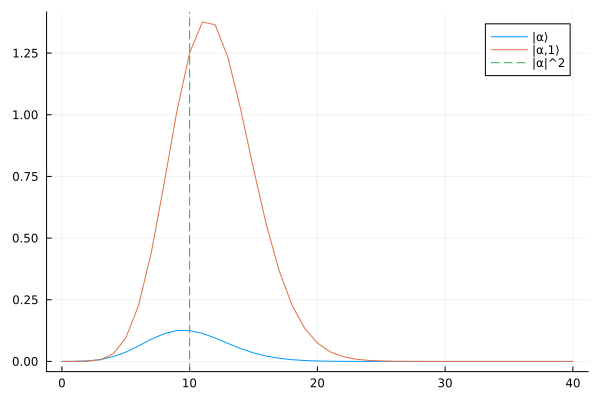

In [3]:
# Function to generate a coherent state |α⟩ in the Fock basis up to normalization
function coherent_state(α::Complex, N::Int)
    state = zeros(ComplexF64, N+1)
    curr_state = 1.0 + 0.0im
    state[1] = curr_state
    for n in 2:(N+1)
        curr_state *= α / sqrt(n-1)
        state[n] = curr_state
    end
    # Normalize the state vector
    return state / norm(state)
end

function excited_coherent_state(α::Complex, N::Int)
    state = zeros(ComplexF64, N+1)
    base_state = coherent_state(α, N)
    for n in 1:N
        state[n+1] = sqrt(n) * base_state[n]
    end
    return state #/ norm(state)
end

# Define parameters
α = 3.0 + 1.0im  # Example coherent state parameter
N = 40  # Number of Fock states to consider

# Generate coherent state
coherent = coherent_state(α, N)

# Plot
plot(0:N, abs2.(coherent), label="|α⟩")
plot!(0:N, abs2.(excited_coherent_state(α, N)), label="|α,1⟩")
# add a vertical line at the peak of the distribution \alpha^2 
vline!([abs(α)^2], label="|α|^2", linestyle=:dash)

Optimized alphas: ComplexF64[7.140631482945547 + 0.1120348554352426im, 7.140638530310916 + 0.11203474531723003im]
Optimized n: [51.00116978406552, 51.001270404719136]
Optimized amplitudes: [-2.84330368212294, 2.843299738953746]
Final residual norm: 7.141428426788646


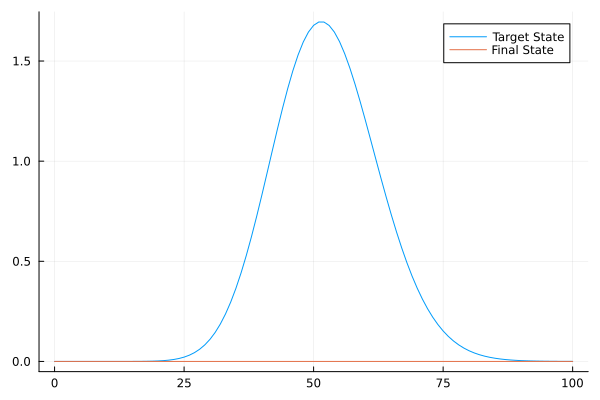

In [27]:
# Function to compute the residual after subtracting a coherent state guess
function coherent_superposition(params, N)
    len_params = length(params)
    if len_params % 3 != 0
        throw(ArgumentError("params must have length 3m"))
    end
    m = len_params ÷ 3
    guess_state = zeros(ComplexF64, N+1)
    for i in 1:m
        amplitude = params[3*(i-1)+1]
        α_guess = Complex(params[3*(i-1)+2], params[3*(i-1)+3])
        guess_state .+= amplitude * coherent_state(α_guess, N)
    end
    return guess_state
end

function residual(params, target_state, N)
    residual_state = target_state .- coherent_superposition(params, N) 
    return residual_state
end

# Function to iteratively subtract the best fit coherent state
function iterative_fit(target_state, N, num_coherent)
    residuals = copy(target_state)
    residual_norm = norm(residuals)
    alphas = []
    amplitudes = []
    curr_params::Vector{Float64} = []
    final_state::Vector{ComplexF64} = zeros(ComplexF64, N+1)    
    
    for i in 1:num_coherent
        # find current maximum in residuals
        objective(params) = norm(residual(params, target_state, N))
        curr_max = argmax(abs2.(residuals[2:end])) 
        n = sqrt(curr_max)
        # find angle at curr_max
        curr_phase = ((target_state[curr_max])/norm(target_state[curr_max]))^(1/(curr_max - 1))*n
        curr_real_alpha = real(curr_phase)
        curr_imag_alpha = imag(curr_phase)
        max_amplitude = exp(-n)*n^(n-1)/gamma(n)
        curr_amplitude = abs(residuals[curr_max])/max_amplitude/2
        # Initial guess for the optimization (can be randomized or based on some heuristic)
        curr_guess = [curr_amplitude, curr_real_alpha, curr_imag_alpha]
        append!(curr_params, curr_guess)
        
        # Optimize to find the best fit coherent state parameters
        result = optimize(objective, curr_params, LBFGS())
        optimized_params = Optim.minimizer(result)
        curr_params = copy(optimized_params)
        amplitudes = curr_params[1:3:end]
        alphas = [Complex(curr_params[2+3*(j-1)], curr_params[3+3*(j-1)]) for j in 1:i]  
        residuals = residual(curr_params, target_state, N)
        residual_norm = norm(residuals)
        final_state = coherent_superposition(optimized_params, N)
    end
    return amplitudes, alphas, residuals, residual_norm, final_state
end

# Define parameters
alpha = 5.0 + 5.0im  # Example coherent state parameter
N = 100  # Number of Fock states to consider
num_coherent = 2  # Number of iterations for fitting

# Generate excited coherent state
target_state = excited_coherent_state(alpha, N)

# Perform iterative fitting<
amplitudes, alphas, residuals, residual_norm, final_state = iterative_fit(target_state, N, num_coherent)

# Print results
println("Optimized alphas: ", alphas)
println("Optimized n: ", abs2.(alphas))
println("Optimized amplitudes: ", amplitudes)
println("Final residual norm: ", residual_norm)

# Plot target_state and final_state
plot(0:N, abs.(target_state), label="Target State")
plot!(0:N, abs.(final_state), label="Final State")

In [23]:
abs2(alpha)

50.0

In [37]:
include("operator_terms.jl")

A = make_term("++--")
B = make_term("--++")
scale_term!(B, -1.0)
B = normal_order(B)
add_terms(A, B)

2-element Vector{Term}:
 Term("", "", "+-", [1, 1], -4.0 - 0.0im, String[], false, true)
 Term("", "", "", Int64[], -2.0 - 0.0im, String[], false, true)

In [ ]:
# Wigner function for a coherent state 